# Tornando visual
Esses códigos abaixo fornecem uma estimativa visual em tempo real de como estão acontecendo as mudanças de pesos e bias para que as ativações dos neurônios sejam feitas e tragam o resultado esperado.


Animação salva como 'neuron_weights_animation.gif'.


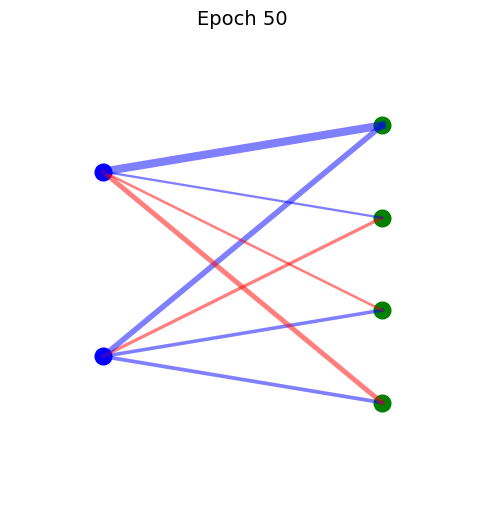

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Gerar dados sintéticos
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Criar modelo simples
model = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='tanh', name='hidden'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# 3. Callback para salvar pesos
class WeightHistory(Callback):
    def __init__(self):
        self.weights = []

    def on_epoch_end(self, epoch, logs=None):
        w = self.model.get_layer('hidden').get_weights()[0]
        self.weights.append(w.copy())

weight_history = WeightHistory()

# 4. Treinar modelo
model.fit(X_train, y_train, epochs=50, verbose=0, callbacks=[weight_history])

# 5. Criar animação com neurônios e conexões
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Posições dos neurônios
input_positions = [(2, 3), (2, 7)]  # 2 neurônios de entrada
hidden_positions = [(8, 2), (8, 4), (8, 6), (8, 8)]  # 4 neurônios ocultos

# Desenhar neurônios
for x, y in input_positions:
    ax.plot(x, y, 'o', color='blue', markersize=12)
for x, y in hidden_positions:
    ax.plot(x, y, 'o', color='green', markersize=12)

# Inicializar conexões
lines = []
for i_pos in input_positions:
    for h_pos in hidden_positions:
        line, = ax.plot([i_pos[0], h_pos[0]], [i_pos[1], h_pos[1]], color='gray', alpha=0.5)
        lines.append(line)

# Função de atualização da animação
def update(frame):
    weights = weight_history.weights[frame]
    ax.set_title(f"Epoch {frame+1}", fontsize=14)
    for i in range(2):  # entrada
        for j in range(4):  # oculto
            weight = weights[i][j]
            idx = i * 4 + j
            lines[idx].set_linewidth(abs(weight) * 5)
            lines[idx].set_color('red' if weight > 0 else 'blue')
    return lines

# Criar animação
ani = animation.FuncAnimation(fig, update, frames=len(weight_history.weights),
                              blit=True, repeat=False)

# Salvar como GIF
ani.save("neuron_weights_animation.gif", writer='pillow', fps=5)
print("Animação salva como 'neuron_weights_animation.gif'.")


# Dividindo uma imagem!
Aqui nós vamos dividir uma imagem e entender como ela é de forma digital, ou seja, como ela é representada em forma de matriz.

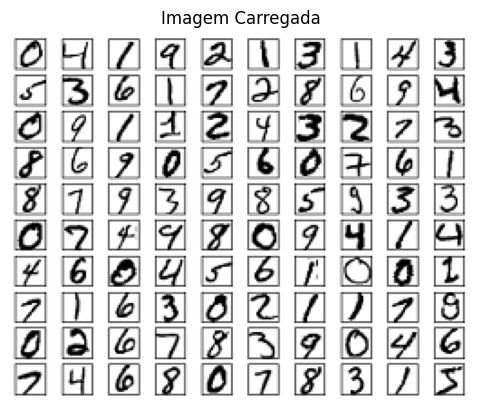

Matriz de pixels da imagem:
[[[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 ...

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]]


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

url = "https://www.deeplearningbook.com.br/wp-content/uploads/2017/12/mnist_100_digits.png"

# Fazer o download da imagem
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Converter a imagem para matriz NumPy
img_array = np.array(img)

# Exibir a imagem
plt.imshow(img_array)
plt.axis('off')
plt.title('Imagem Carregada')
plt.show()

# Exibir a matriz de pixels
print("Matriz de pixels da imagem:")
print(img_array)


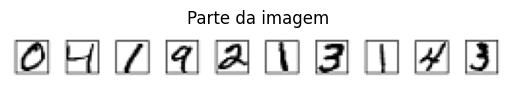

In [3]:
part_img = img_array[0:100][0:23]
plt.imshow(part_img)
plt.axis('off')
plt.title('Parte da imagem')
plt.show()

# Neurônios

In [4]:
import numpy as np

def neuron(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

inputs = np.array([1.0, 2.0])
weights = np.array([0.5, -1.5])
bias = 0.1

output = neuron(inputs, weights, bias)
print("Output:", output)

Output: -2.4


In [5]:
import numpy as np

class SimpleNeuron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, inputs):
        self.inputs = inputs
        self.output = self.sigmoid(np.dot(inputs, self.weights) + self.bias)
        return self.output

    def backward(self, target):
        error = target - self.output
        delta = error * self.sigmoid_derivative(self.output)
        self.weights += self.learning_rate * delta * self.inputs
        self.bias += self.learning_rate * delta
        return error

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            total_error = 0
            for inputs, target in zip(X, y):
                self.forward(inputs)
                error = self.backward(target)
                total_error += error**2
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Error: {total_error:.4f}")


In [6]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])  # Saídas esperadas para OR lógico

In [7]:
SimpleNeuron(2).train(X, y)

Epoch 0, Error: 0.4269
Epoch 100, Error: 0.2939
Epoch 200, Error: 0.2182
Epoch 300, Error: 0.1714
Epoch 400, Error: 0.1400
Epoch 500, Error: 0.1176
Epoch 600, Error: 0.1008
Epoch 700, Error: 0.0879
Epoch 800, Error: 0.0777
Epoch 900, Error: 0.0694
Epoch 1000, Error: 0.0626
Epoch 1100, Error: 0.0569
Epoch 1200, Error: 0.0521
Epoch 1300, Error: 0.0480
Epoch 1400, Error: 0.0444
Epoch 1500, Error: 0.0413
Epoch 1600, Error: 0.0386
Epoch 1700, Error: 0.0362
Epoch 1800, Error: 0.0341
Epoch 1900, Error: 0.0322
Epoch 2000, Error: 0.0305
Epoch 2100, Error: 0.0289
Epoch 2200, Error: 0.0275
Epoch 2300, Error: 0.0262
Epoch 2400, Error: 0.0250
Epoch 2500, Error: 0.0239
Epoch 2600, Error: 0.0229
Epoch 2700, Error: 0.0220
Epoch 2800, Error: 0.0212
Epoch 2900, Error: 0.0204
Epoch 3000, Error: 0.0196
Epoch 3100, Error: 0.0189
Epoch 3200, Error: 0.0183
Epoch 3300, Error: 0.0177
Epoch 3400, Error: 0.0171
Epoch 3500, Error: 0.0166
Epoch 3600, Error: 0.0161
Epoch 3700, Error: 0.0156
Epoch 3800, Error: 0.015

# Images

In [8]:
from torchvision import datasets

mnist = datasets.MNIST(root='./data', train=True, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.69MB/s]


In [9]:
print("Tamanho dos dados de treino:", len(mnist.train_data))
print("Shape:", mnist.train_data[0].shape)
print("Tipo:", type(mnist.train_data[0]), "\n")

Tamanho dos dados de treino: 60000
Shape: torch.Size([28, 28])
Tipo: <class 'torch.Tensor'> 



/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [10]:
mnist.data[0].shape

torch.Size([28, 28])

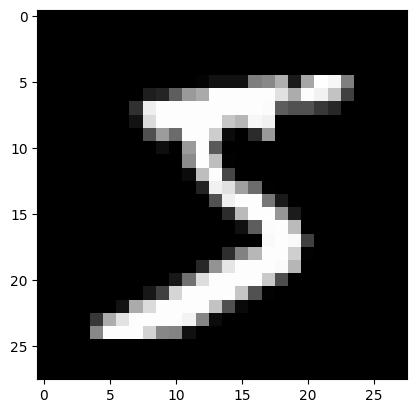

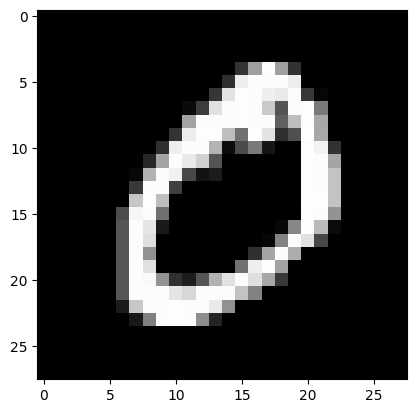

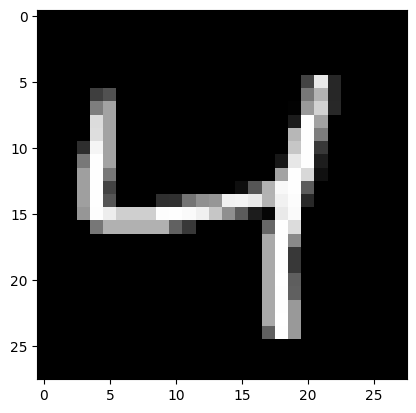

In [11]:
for i in range(3):
  plt.imshow(mnist.data[i], cmap='gray')
  plt.show()

# Reconhecendo digitos
URL livro: https://www.deeplearningbook.com.br/


marcação de capitulo: 18


In [12]:
import random
# vamos criar uma classe de rede
# sizes é um vetor que contém o tamanho das redes neurais em cada camada. ex: [2, 5, 6, 1]
class Network(object):
    def __init__(self,sizes):
      self.num_layers = len(sizes)
      self.sizes = sizes
      self.biases = [np.random.randn(y,1) for y in sizes[1:]]
      self.weights = [np.random.randn(y,x) for x,y in zip(sizes[:-1],sizes[1:])]

    def sigmoid(self,z):
      return 1.0/(1.0+np.exp(-z))

    def feedforward(self,a):
      for b,w in zip(self.biases,self.weights):
        a = self.sigmoid(np.dot(w,a)+b)
      return a

    def SGD(self,training_data,epochs,mini_batch_size,eta,test_data=None):
      training_data = list(training_data)
      n = len(training_data)

      if test_data:
        test_data = list(test_data)
        n_test = len(test_data)
      for j in range(epochs):
        random.shuffle(training_data)
        mini_batches = [training_data[k:k+mini_batch_size] for k in range(0,n,mini_batch_size)]
        for mini_batch in mini_batches:
          self.update_mini_batch(mini_batch,eta)

        if test_data:
          print("Epoch {} : {} / {}".format(j,self.evaluate(test_data),n_test))
        else:
          print("Epoch {} complete".format(j))

    def update_mini_batch(self, mini_batch, eta):
      nabla_b = [np.zeros(b.shape) for b in self.biases]
      nabla_w = [np.zeros(w.shape) for w in self.weights]
      for x, y in mini_batch:
        delta_nabla_b, delta_nabla_w = self.backprop(x, y)
        nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
        nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
      self.weights = [w-(eta/len(mini_batch))*nw
                      for w, nw in zip(self.weights, nabla_w)]
      self.biases = [b-(eta/len(mini_batch))*nb
                     for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
      nabla_b = [np.zeros(b.shape) for b in self.biases]
      nabla_w = [np.zeros(w.shape) for w in self.weights]

      activation = x

      activations = [x]
      zs = []
      for b, w in zip(self.biases, self.weights):
        z = np.dot(w, activation)+b
        zs.append(z)
        activation = self.sigmoid(z)
        activations.append(activation)

      delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(zs[-1])
      nabla_b[-1] = delta
      nabla_w[-1] = np.dot(delta, activations[-2].transpose())

      for l in range(2, self.num_layers):
        z = zs[-l]
        sp = self.sigmoid_prime(z)
        delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
        nabla_b[-l] = delta
        nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())

      return (nabla_b, nabla_w)

In [13]:
# exemplo de uso
rede1 = Network([2,3,1])
print("W:",rede1.weights)
print("B:",rede1.biases)

W: [array([[ 0.7973339 , -1.04678732],
       [ 0.461603  , -1.54519531],
       [ 0.89313134, -0.85630197]]), array([[-0.1619254 ,  0.26449715, -1.37132641]])]
B: [array([[-0.33124742],
       [ 0.50805008],
       [ 0.3462099 ]]), array([[0.56307534]])]


## exemplo com modelo MLP
Já pronto para uso


In [14]:
def rotate_vector(v, theta_deg):
    theta_rad = np.radians(theta_deg)
    rotation_matrix = np.array([
        [np.cos(theta_rad), -np.sin(theta_rad)],
        [np.sin(theta_rad),  np.cos(theta_rad)]
    ])
    h, w = v.shape
    center = np.array([w // 2, h // 2])
    rotated = np.zeros_like(v)
    for y in range(h):
        for x in range(w):
            pixel = v[y, x]
            coord = np.array([x, y]) - center
            new_coord = rotation_matrix @ coord + center
            new_x, new_y = new_coord.round().astype(int)
            if 0 <= new_x < w and 0 <= new_y < h:
                rotated[new_y, new_x] = pixel
    return rotated


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF


base_transform = transforms.Compose([
    transforms.ToTensor(),                         # -> float32 [C,H,W] em [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),    # média e desvio padrão típicos do MNIST
])


# 1. Pré-processamento dos dados
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
rand_rot_transform = transforms.Compose([
    transforms.RandomRotation(
        degrees=15,                         # -15 a +15
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    base_transform,
])

train_orig = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_randrot = datasets.MNIST(root='./data', train=True, download=True, transform=rand_rot_transform)
train_dataset = ConcatDataset([train_orig, train_randrot])

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [25]:
len(train_dataset)

120000

In [27]:
# 2. Definição do modelo MLP
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
        )


    def forward(self, x):
        return self.model(x)

# 3. Treinamento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

epochs = 30
early_stop = False
for epoch in range(epochs):
    if early_stop:
      break
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        if round(loss.item(), 4) == 0.0001:
          early_stop = True
          break
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} concluída. ", loss.item())

# 4. Avaliação
model.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Acurácia no teste: {100. * correct / len(test_loader.dataset):.2f}%")


Epoch 1 concluída.  0.12505486607551575
Epoch 2 concluída.  0.1455441117286682
Epoch 3 concluída.  0.028660399839282036
Epoch 4 concluída.  0.03499334305524826
Epoch 5 concluída.  0.11962487548589706
Epoch 6 concluída.  0.043782178312540054
Epoch 7 concluída.  0.09039013087749481
Epoch 8 concluída.  0.012862622737884521
Epoch 9 concluída.  0.039473362267017365
Epoch 10 concluída.  0.08793839067220688
Epoch 11 concluída.  0.0037128066178411245
Epoch 12 concluída.  0.0006223474047146738
Epoch 13 concluída.  0.006101413629949093
Epoch 14 concluída.  0.043211035430431366
Epoch 15 concluída.  0.018896348774433136
Epoch 16 concluída.  0.015756068751215935
Epoch 17 concluída.  0.06790323555469513
Epoch 18 concluída.  0.0015049140201881528
Epoch 19 concluída.  0.011881709098815918
Epoch 20 concluída.  0.0029169046320021152
Epoch 21 concluída.  0.030031178146600723
Epoch 22 concluída.  0.002338496968150139
Epoch 23 concluída.  0.02246064692735672
Epoch 24 concluída.  0.001060717971995473
Epoch 

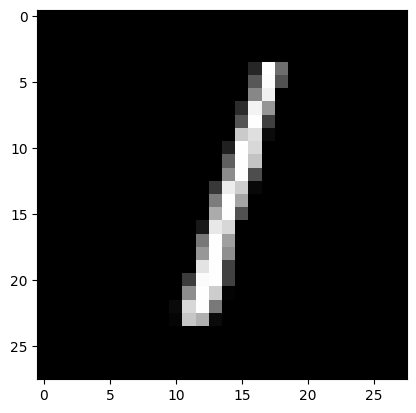

Dígito previsto: 1


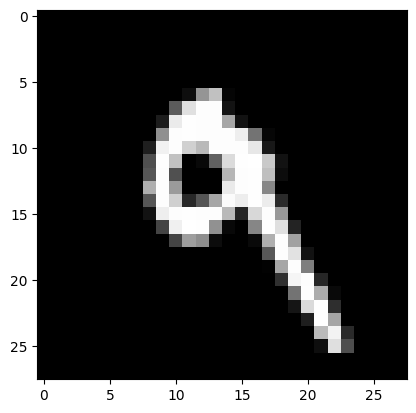

Dígito previsto: 9


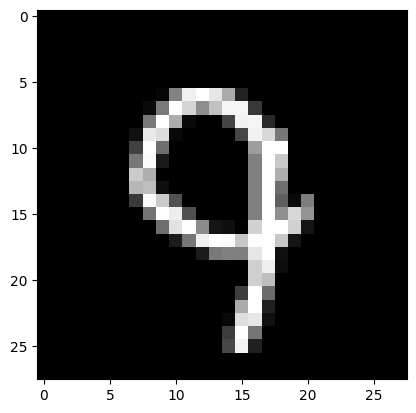

Dígito previsto: 9


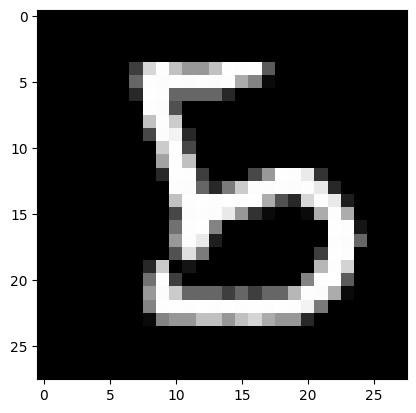

Dígito previsto: 8


In [38]:
# apresenta erros no index 720
index = [2, 7, 999, 720]
for i in index:
  plt.imshow(dataset.data[i], cmap='gray')
  plt.show()

  with torch.no_grad():
      output = model(dataset.data[i].unsqueeze(0).float())
      pred = output.argmax(dim=1)
      print(f"Dígito previsto: {pred.item()}")


# faces

In [19]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


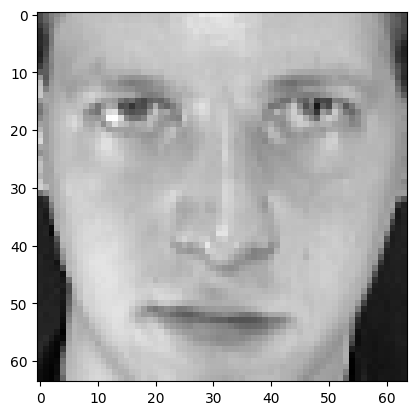

In [20]:
plt.imshow(faces.images[2], cmap="gray")
plt.show()